# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

titanic_df = pd.read_csv('titanic_passengers.csv')

titanic_df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
titanic_df['Fare'].mean()

32.204207968574636

In [3]:
titanic_df['Fare'].median()

14.4542

In [4]:
titanic_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

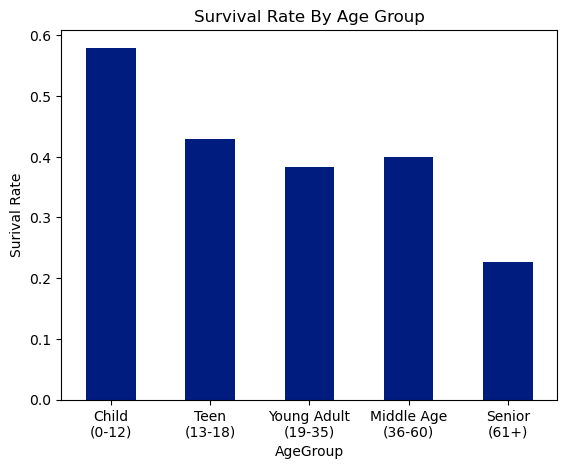

0    (18, 35]
1    (35, 60]
2    (18, 35]
3    (18, 35]
4    (18, 35]
Name: AgeGroup, dtype: category
Categories (5, interval[int64, right]): [(0, 12] < (12, 18] < (18, 35] < (35, 60] < (60, 100]]

In [22]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-dark-palette')

titanic_df = pd.read_csv('titanic_passengers.csv')

titanic_df["AgeGroup"] = pd.cut(titanic_df["Age"], bins=[0, 12, 18, 35, 60, 100])
age_surv   = titanic_df.groupby("AgeGroup", observed=True)["Survived"].mean()
age_surv.plot(kind='bar')
plt.title('Survival Rate By Age Group')
plt.ylabel('Surival Rate')
original_positions=[0,1,2,3,4]
new_names=['Child\n(0-12)', 'Teen\n(13-18)', 'Young Adult\n(19-35)', "Middle Age\n(36-60)", "Senior\n(61+)"]
plt.xticks(original_positions, new_names,rotation=0)
plt.show()

I chose the age groups at the lower end with children 12 and under and teens being seperated because i had a feeling that back in those times people were viewed as adults to a greater extent when they reached their teenage years. So when they priotized women and children for getting them to safety it made the most sense to seperate the people that they would most likely consider as "children" in those times. On the higher end I was expecting a drop off the older the age went and that's mostly what happened with the oldest age group being the least likely to survive.

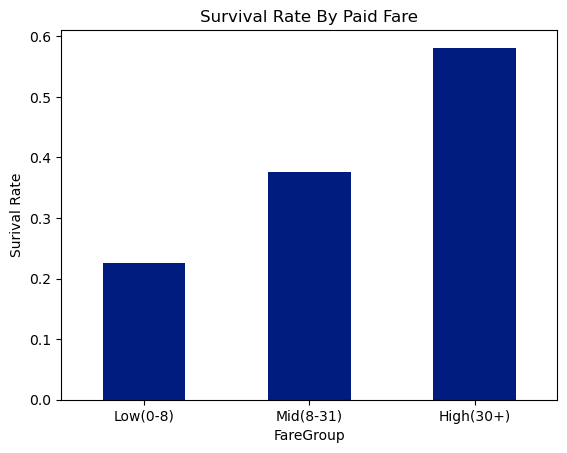

In [7]:
titanic_df["FareGroup"] = pd.cut(titanic_df["Fare"], bins=[0, 8, 31, 600])
fare_surv= titanic_df.groupby("FareGroup", observed=True)["Survived"].mean()
fare_surv.plot(kind='bar')
plt.title('Survival Rate By Paid Fare')
plt.ylabel('Surival Rate')
original_positions=[0,1,2]
new_names=['Low(0-8)', 'Mid(8-31)', 'High(30+)']
plt.xticks(original_positions, new_names,rotation=0)
plt.show()

I chose to only have 3 groups which basically break the passengers into the first quartile, second and third quartile, and fourth quartile. There wasn't really that much thought past that but the result being an almost linear increase in survival rate by amount paid makes sense.

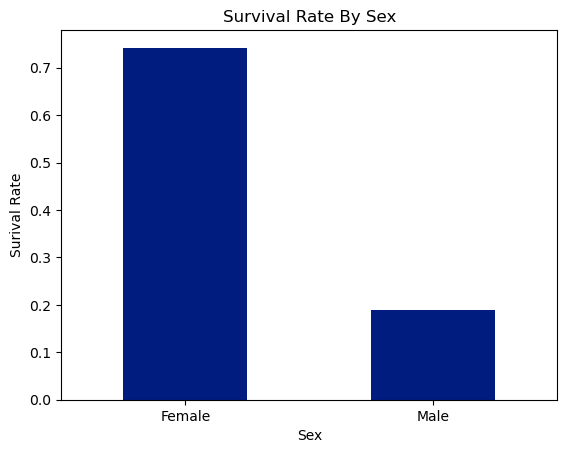

In [8]:
sex_surv   = titanic_df.groupby("Sex")["Survived"].mean()
sex_surv.plot(kind='bar')
plt.title('Survival Rate By Sex')
plt.ylabel('Surival Rate')
original_positions=[0,1]
new_names=['Female', 'Male']
plt.xticks(original_positions, new_names,rotation=0)
plt.show()

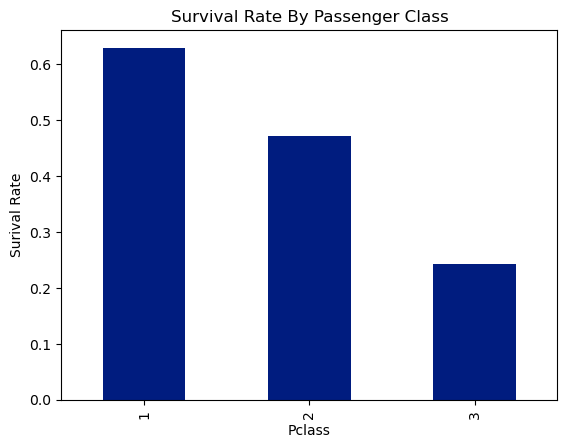

In [9]:
class_surv   = titanic_df.groupby("Pclass")["Survived"].mean()
class_surv.plot(kind='bar')
plt.title('Survival Rate By Passenger Class')
plt.ylabel('Surival Rate')
plt.show()

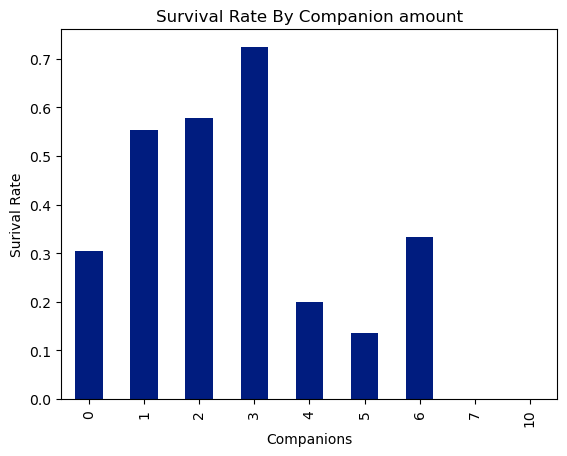

In [21]:
titanic_df["Companions"] = titanic_df["SibSp"] + titanic_df["Parch"]
comp_surv  = titanic_df.groupby("Companions")["Survived"].mean()
comp_surv.plot(kind='bar')
plt.title('Survival Rate By Companion amount')
plt.ylabel('Surival Rate')
plt.show()

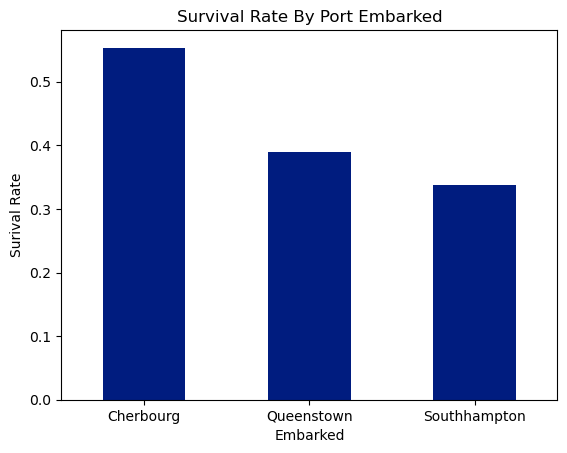

In [12]:
port_surv  = titanic_df.groupby("Embarked")["Survived"].mean()
port_surv.plot(kind='bar')
plt.title('Survival Rate By Port Embarked')
plt.ylabel('Surival Rate')
original_positions=[0,1,2]
new_names=['Cherbourg', 'Queenstown', 'Southhampton']
plt.xticks(original_positions, new_names,rotation=0)
plt.show()

In [25]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,"(18, 35]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(35, 60]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,"(18, 35]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,"(18, 35]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,"(18, 35]"


In [42]:
most_likely_theoretical = titanic_df.loc[ (titanic_df['Age'] < 12) &
                      (titanic_df['Fare'] > 30) &
                      (titanic_df['Sex'] == 'female') &
                      (titanic_df['Pclass'] == 1) &
                      (titanic_df['SibSp'] + titanic_df['Parch'] > 1) &
                      (titanic_df['Embarked'] == 'C')]
most_likely_theoretical.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup


So if there were a passenger with those exact traits they would be the most likely to survive but for the sake of actually getting a result ill loosen the restrictions until I can get a usable one.

In [49]:
most_likely = titanic_df.loc[ (titanic_df['Age'] <= 16) &
                      (titanic_df['Fare'] > 30) &
                      (titanic_df['Sex'] == 'female') &
                      (titanic_df['Pclass'] == 1) &
                      (titanic_df['SibSp'] + titanic_df['Parch'] > 0) &
                      (titanic_df['Embarked'] == 'C')]
most_likely.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C,"(12, 18]"


In [48]:
least_likely = titanic_df.loc[ (titanic_df['Age'] > 61) &
                      (titanic_df['Fare'] < 8) &
                      (titanic_df['Sex'] == 'male') &
                      (titanic_df['Pclass'] == 3) &
                      (titanic_df['SibSp'] + titanic_df['Parch'] == 0) &
                      (titanic_df['Embarked'] == 'S')]
least_likely.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S,"(60, 100]"


Interestingly the predictor was correct for both passengers.

Jean Gertrude Hippach had two brothers that died at the matinee performance of a musical due to an arc light catching one of the curtains on fire in 1903.

Johan Svensson was the oldest person aboard the Titanic.